
# Orange Exercise Submission

**Name:** VIVEK GOWDA S  
**SRN:** PES1UG23AM355  
**Section:** F  
**Course:** UE23AM343BB2 - Large Language Models and Their Applications

This notebook uses the following Mistral setup:
- Text generation: `devstral-2512`
- Embeddings: `mistral-embed-2312`
- Image generation: Mistral agent `ag_019d1958ce537459aa45f73134929b60`

Note: The mother tongue is currently assumed as **Kannada** because it was not provided explicitly. Change the variable in Question 3 if needed.


In [1]:
# If needed, run this once inside Jupyter.
# %pip install mistralai

import json
import os
import textwrap
import urllib.request
from html.parser import HTMLParser
from pathlib import Path

from IPython.display import Image, Markdown, display
from mistralai import Mistral


def load_env_file(env_path=".env"):
    env_file = Path(env_path)
    if not env_file.exists():
        raise FileNotFoundError(f"{env_path} not found. Create it and add MISTRAL_API_KEY.")

    for line in env_file.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip())


load_env_file()

In [2]:
# Configuration
NAME = "VIVEK GOWDA S"
SRN = "PES1UG23AM355"
SECTION = "F"
TEXT_MODEL = "devstral-2512"
EMBED_MODEL = "mistral-embed-2312"
MOTHER_TONGUE = "Kannada"  # Assumed. Change this if needed.

MONUMENT = "Pyramid"
ANIMAL = "Eagle"
BACKGROUND = "Sky with moon"

api_key = os.environ.get("MISTRAL_API_KEY")
if not api_key:
    raise ValueError("Set MISTRAL_API_KEY in .env before running this notebook.")

IMAGE_AGENT_ID = os.environ.get("MISTRAL_IMAGE_AGENT_ID")
if not IMAGE_AGENT_ID:
    raise ValueError("Set MISTRAL_IMAGE_AGENT_ID in .env before running this notebook.")

IMAGE_AGENT_VERSION = int(os.environ.get("MISTRAL_IMAGE_AGENT_VERSION", "1"))

client = Mistral(api_key=api_key)
output_dir = Path("orange_outputs")
output_dir.mkdir(exist_ok=True)

print("Configuration loaded successfully.")
print(f"Text model: {TEXT_MODEL}")
print(f"Embedding model: {EMBED_MODEL}")
print(f"Image agent: {IMAGE_AGENT_ID}")
print(f"Image agent version: {IMAGE_AGENT_VERSION}")

Configuration loaded successfully.
Text model: devstral-2512
Embedding model: mistral-embed-2312
Image agent: ag_019d1958ce537459aa45f73134929b60
Image agent version: 1


## Question 1 - Character paragraph

In [3]:

character_name = "Shivaji Maharaj"
q1_prompt = f"""
Write one small original paragraph about {character_name}.
Keep it around 80 to 110 words.
Make it clear, factual, and suitable for a student submission.
Do not use bullet points.
""".strip()

q1_response = client.chat.complete(
    model=TEXT_MODEL,
    messages=[
        {"role": "system", "content": "You write concise academic content."},
        {"role": "user", "content": q1_prompt},
    ],
)

q1_text = q1_response.choices[0].message.content
print(q1_text)


Shivaji Maharaj, born in 1630, was a visionary Maratha warrior-king who laid the foundation of the Maratha Empire in western India. Renowned for his administrative acumen and military strategies, he established a competent and progressive civil rule with well-structured administrative organizations. Shivaji implemented a humane approach towards his subjects, promoting religious tolerance and protecting women's honor. His innovative military tactics, such as guerrilla warfare, enabled him to challenge the dominant Mughal Empire successfully. Shivaji's coronation in 1674 marked the beginning of a new era, and his legacy continues to inspire generations for his courage, justice, and good governance.


## Question 2 - Dense embedding

In [4]:

# Using a word that starts with the first character of the name: V
embedding_word = "victory"

q2_response = client.embeddings.create(
    model=EMBED_MODEL,
    inputs=[embedding_word],
)

q2_embedding = q2_response.data[0].embedding
print(f"Word used: {embedding_word}")
print(f"Embedding length: {len(q2_embedding)}")
print("Dense embedding vector:")
print(q2_embedding)


Word used: victory
Embedding length: 1024
Dense embedding vector:
[-0.01131439208984375, -0.0036792755126953125, 0.0012331008911132812, 0.03564453125, 0.01126861572265625, 0.0258331298828125, 0.036041259765625, -0.0294342041015625, 0.0026912689208984375, -0.045867919921875, -0.0268402099609375, 0.0584716796875, -0.083740234375, -0.038055419921875, -0.033233642578125, 0.0478515625, -0.0028285980224609375, 0.0105133056640625, 0.0225372314453125, 0.00795745849609375, -0.04425048828125, -0.044464111328125, -0.01412200927734375, -0.023834228515625, -0.0126190185546875, -0.004131317138671875, -0.04425048828125, -0.00365447998046875, -0.01432037353515625, 0.0119171142578125, 0.0038547515869140625, 0.005733489990234375, -0.005382537841796875, 0.0229339599609375, 0.036834716796875, -0.0009074211120605469, -0.03204345703125, -0.010162353515625, 0.032257080078125, 0.0161285400390625, -0.013214111328125, -0.033050537109375, 0.00991058349609375, -0.014923095703125, -0.0304412841796875, 0.0028285980

## Question 3 - Web paragraph translation

In [5]:

class ParagraphParser(HTMLParser):
    def __init__(self):
        super().__init__()
        self.in_p = False
        self.parts = []
        self.current = []

    def handle_starttag(self, tag, attrs):
        if tag == "p":
            self.in_p = True
            self.current = []

    def handle_endtag(self, tag):
        if tag == "p" and self.in_p:
            text = " ".join("".join(self.current).split())
            if text:
                self.parts.append(text)
            self.in_p = False
            self.current = []

    def handle_data(self, data):
        if self.in_p:
            self.current.append(data)

web_url = "https://www.iana.org/help/example-domains"
html = urllib.request.urlopen(web_url).read().decode("utf-8", errors="ignore")
parser = ParagraphParser()
parser.feed(html)

english_paragraph = parser.parts[0]
print("Mother tongue:", MOTHER_TONGUE)
print("Source URL:", web_url)
print("English paragraph from web:")
print(english_paragraph)


Mother tongue: Kannada
Source URL: https://www.iana.org/help/example-domains
English paragraph from web:
As described in RFC 2606 and RFC 6761, a number of domains such as example.com and example.org are maintained for documentation purposes. These domains may be used as illustrative examples in documents without prior coordination with us. They are not available for registration or transfer.


In [6]:

q3_prompt = f"""
Translate the following English paragraph into {MOTHER_TONGUE}.
Return only the translated paragraph.

English paragraph:
{english_paragraph}
""".strip()

q3_response = client.chat.complete(
    model=TEXT_MODEL,
    messages=[
        {"role": "system", "content": "You are an accurate translator."},
        {"role": "user", "content": q3_prompt},
    ],
)

translated_paragraph = q3_response.choices[0].message.content
print(f"Translated paragraph in {MOTHER_TONGUE}:")
print(translated_paragraph)


Translated paragraph in Kannada:
RFC 2606 ಮತ್ತು RFC 6761 ರಲ್ಲಿ ವಿವರಿಸಲಾದಂತೆ, example.com ಮತ್ತು example.org ನಂತಹ ಹಲವಾರು ಡೊಮೇನ್‌ಗಳನ್ನು ದಸ್ತಾವೇಜು ಉದ್ದೇಶಗಳಿಗಾಗಿ ನಿರ್ವಹಿಸಲಾಗುತ್ತದೆ. ಈ ಡೊಮೇನ್‌ಗಳನ್ನು ನಮ್ಮೊಂದಿಗೆ ಮುಂಚಿತವಾಗಿ ಸಮನ್ವಯಗೊಳಿಸದೆ ದಸ್ತಾವೇಜುಗಳಲ್ಲಿ ಉದಾಹರಣೆಗಳಾಗಿ ಬಳಸಬಹುದು. ಅವುಗಳನ್ನು ನೋಂದಣಿ ಅಥವಾ ವರ್ಗಾವಣೆಗೆ ಲಭ್ಯವಿಲ್ಲ.


## Question 4 - Image generation

In [8]:
import time
from mistralai.models import SDKError

image_prompt = f"""
Generate a realistic image of {MONUMENT} with an {ANIMAL} on top of the monument.
Use a {BACKGROUND} in the background.
Make the composition visually clear and centered.
""".strip()

last_error = None
for attempt in range(1, 6):
    try:
        q4_response = client.beta.conversations.start(
            agent_id=IMAGE_AGENT_ID,
            inputs=[
                {"role": "user", "content": image_prompt}
            ],
        )
        print(f"Image generation succeeded on attempt {attempt}.")
        print(q4_response.model_dump_json(indent=2))
        break
    except SDKError as exc:
        last_error = exc
        error_text = str(exc)
        if 'rate limit' in error_text.lower() and attempt < 5:
            wait_seconds = 10 * attempt
            print(f"Attempt {attempt} hit rate limit. Waiting {wait_seconds} seconds before retrying...")
            time.sleep(wait_seconds)
            continue
        raise
else:
    raise last_error

Image generation succeeded on attempt 1.
{
  "conversation_id": "conv_019d196a2d4e731d975c8053be3ee6e8",
  "outputs": [
    {
      "name": "image_generation",
      "arguments": "{\"prompt\": \"A realistic image of a pyramid with a majestic eagle perched on top of the monument. The scene is set against a clear night sky with a full moon visible in the background. The composition is visually balanced, centered, and well-lit to highlight the details of the pyramid and the eagle.\"}",
      "object": "entry",
      "type": "tool.execution",
      "created_at": "2026-03-23T06:38:02.264513Z",
      "completed_at": "2026-03-23T06:38:14.934391Z",
      "id": "tool_exec_019d196a2e187254a6017c4c94b64afd",
      "info": {}
    },
    {
      "content": [
        {
          "text": "Here is the image you requested:\n\n",
          "type": "text"
        },
        {
          "tool": "image_generation",
          "file_id": "58d91709-45e4-42f6-8850-a03f7ad6a974",
          "type": "tool_file",


Saved generated image to: orange_outputs/q4_pyramid_eagle.png


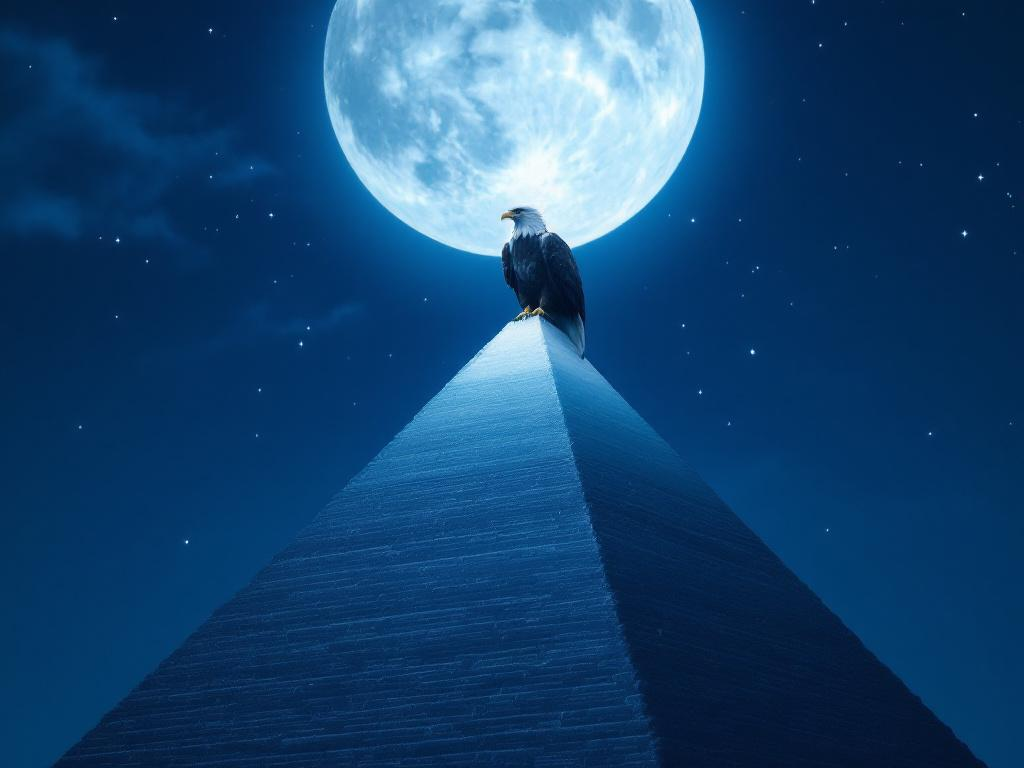

In [9]:
# Extract the generated file id from the conversation response.
file_item = None
for output in q4_response.outputs:
    content = getattr(output, "content", None)
    if isinstance(content, list):
        for item in content:
            item_type = item.get("type") if isinstance(item, dict) else getattr(item, "type", None)
            if item_type == "tool_file":
                file_item = item if isinstance(item, dict) else item.model_dump()
                break
    if file_item:
        break

if not file_item:
    raise ValueError("No generated image file was returned by the image agent.")

file_id = file_item["file_id"]
file_ext = file_item.get("file_type", "png")
image_path = output_dir / f"q4_pyramid_eagle.{file_ext}"

file_response = client.files.download(file_id=file_id)
image_bytes = file_response.read()
image_path.write_bytes(image_bytes)

print(f"Saved generated image to: {image_path}")
display(Image(filename=str(image_path)))


## Final Notes

- Question 1 uses `devstral-2512` for paragraph generation.
- Question 2 uses `mistral-embed-2312` to print the dense embedding of the word `victory`.
- Question 3 fetches a paragraph from the web and translates it to the stated mother tongue.
- Question 4 uses the given Mistral agent to generate and save the required image.
